In [81]:
!python "analysis/create_baseline_modeling_dataset.py"

## Source
- players_quarters_final.csv
- player_appearance_pass.csv
- output: data\baseline_modeling

## Requested 60 / 20 / 20 split
split  rows  fixtures  player_appearances  players  positives  positive_rate  row_share
 test   633         5                 147       95         29       0.045814   0.198807
train  1896        20                 493      263        107       0.056435   0.595477
  val   655         6                 162      143         44       0.067176   0.205716

## Added baseline extension features
- last_15_received_succ
- last_15_received_unsucc
- cumul_received_succ
- cumul_received_unsucc
- cumul_in_game_time


In [83]:
import pandas as pd


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

In [85]:
train = pd.read_csv("data/baseline_modeling/baseline_train_model_ready.csv")
val = pd.read_csv("data/baseline_modeling/baseline_val_model_ready.csv")
test = pd.read_csv("data/baseline_modeling/baseline_test_model_ready.csv")


In [87]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   checkpoint                1896 non-null   str    
 1   position                  1896 non-null   str    
 2   is_home                   1896 non-null   bool   
 3   formation                 1896 non-null   str    
 4   subbed                    1896 non-null   bool   
 5   last15_sprints            1896 non-null   int64  
 6   last15_hsr                1896 non-null   int64  
 7   last15_distance           1896 non-null   float64
 8   last15_mean_max_speed     1896 non-null   float64
 9   last15_peak_speed         1896 non-null   float64
 10  last15_shots              1896 non-null   int64  
 11  last15_shots_on_target    1896 non-null   int64  
 12  last15_shots_under_press  1896 non-null   int64  
 13  last15_shots_top_third    1896 non-null   int64  
 14  cumul_sprints      

In [113]:
val.info()

<class 'pandas.DataFrame'>
RangeIndex: 655 entries, 0 to 654
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   checkpoint                655 non-null    str    
 1   position                  655 non-null    str    
 2   is_home                   655 non-null    bool   
 3   formation                 655 non-null    str    
 4   subbed                    655 non-null    bool   
 5   last15_sprints            655 non-null    int64  
 6   last15_hsr                655 non-null    int64  
 7   last15_distance           655 non-null    float64
 8   last15_mean_max_speed     655 non-null    float64
 9   last15_peak_speed         655 non-null    float64
 10  last15_shots              655 non-null    int64  
 11  last15_shots_on_target    655 non-null    int64  
 12  last15_shots_under_press  655 non-null    int64  
 13  last15_shots_top_third    655 non-null    int64  
 14  cumul_sprints        

In [115]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   checkpoint                633 non-null    str    
 1   position                  633 non-null    str    
 2   is_home                   633 non-null    bool   
 3   formation                 633 non-null    str    
 4   subbed                    633 non-null    bool   
 5   last15_sprints            633 non-null    int64  
 6   last15_hsr                633 non-null    int64  
 7   last15_distance           633 non-null    float64
 8   last15_mean_max_speed     633 non-null    float64
 9   last15_peak_speed         633 non-null    float64
 10  last15_shots              633 non-null    int64  
 11  last15_shots_on_target    633 non-null    int64  
 12  last15_shots_under_press  633 non-null    int64  
 13  last15_shots_top_third    633 non-null    int64  
 14  cumul_sprints        

In [89]:
target = "scored_after"

X_train_df = train.drop(columns=[target]).copy()
y_train = train[target].copy()

X_val_df = val.drop(columns=[target]).copy()
y_val = val[target].copy()

X_test_df = test.drop(columns=[target]).copy()
y_test = test[target].copy()

cat_cols = X_train_df.select_dtypes(include=["object", "category", "string", "bool"]).columns.to_list()
num_cols = X_train_df.select_dtypes(include=["number"]).columns.to_list()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['checkpoint', 'position', 'is_home', 'formation', 'subbed']
Numeric: ['last15_sprints', 'last15_hsr', 'last15_distance', 'last15_mean_max_speed', 'last15_peak_speed', 'last15_shots', 'last15_shots_on_target', 'last15_shots_under_press', 'last15_shots_top_third', 'cumul_sprints', 'cumul_hsr', 'cumul_distance', 'cumul_mean_max_speed', 'cumul_peak_speed', 'cumul_shots', 'cumul_shots_on_target', 'cumul_shots_under_press', 'cumul_shots_top_third', 'cumul_in_game_time', 'last_15_received_succ', 'last_15_received_unsucc', 'cumul_received_succ', 'cumul_received_unsucc']


In [91]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [105]:
tree_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        random_state=42,
        class_weight = "balanced"
    ))
])

In [107]:
tree_pipe.fit(X_train_df, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [117]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, brier_score_loss
import numpy as np

# --- Decision Tree: validation ---
y_val_pred = tree_pipe.predict(X_val_df)
y_val_prob = tree_pipe.predict_proba(X_val_df)[:, 1]

val_acc = accuracy_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_prob)
val_brier = brier_score_loss(y_val, y_val_prob)

baseline_prob_val = np.full(len(y_val), y_train.mean())
baseline_brier_val = brier_score_loss(y_val, baseline_prob_val)

print("=== Decision Tree: Validation ===")
print("Accuracy:", val_acc)
print("ROC AUC:", val_auc)
print("Brier score:", val_brier)
print("Baseline Brier score:", baseline_brier_val)
print(classification_report(y_val, y_val_pred))

# --- Decision Tree: test ---
y_test_pred = tree_pipe.predict(X_test_df)
y_test_prob = tree_pipe.predict_proba(X_test_df)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)
test_brier = brier_score_loss(y_test, y_test_prob)

baseline_prob_test = np.full(len(y_test), y_train.mean())
baseline_brier_test = brier_score_loss(y_test, baseline_prob_test)

print("\n=== Decision Tree: Test ===")
print("Accuracy:", test_acc)
print("ROC AUC:", test_auc)
print("Brier score:", test_brier)
print("Baseline Brier score:", baseline_brier_test)
print(classification_report(y_test, y_test_pred))

=== Decision Tree: Validation ===
Accuracy: 0.5694656488549619
ROC AUC: 0.6912289837821752
Brier score: 0.24115721094118256
Baseline Brier score: 0.0627783834846012
              precision    recall  f1-score   support

           0       0.97      0.56      0.71       611
           1       0.11      0.75      0.19        44

    accuracy                           0.57       655
   macro avg       0.54      0.65      0.45       655
weighted avg       0.91      0.57      0.67       655


=== Decision Tree: Test ===
Accuracy: 0.5529225908372828
ROC AUC: 0.7175725051381594
Brier score: 0.23402035266067964
Baseline Brier score: 0.04382750734517421
              precision    recall  f1-score   support

           0       0.98      0.54      0.70       604
           1       0.08      0.83      0.15        29

    accuracy                           0.55       633
   macro avg       0.53      0.68      0.42       633
weighted avg       0.94      0.55      0.67       633



                          feature  mean_abs_shap
0                 cat__position_A       0.025910
1      num__cumul_received_unsucc       0.019210
2            num__last15_distance       0.012246
3           num__cumul_peak_speed       0.010531
4             num__cumul_distance       0.010155
5               cat__subbed_False       0.010041
6                  num__cumul_hsr       0.005917
7          cat__formation_4-2-3-1       0.005572
8         num__cumul_in_game_time       0.004925
9      num__last_15_received_succ       0.004864
10             num__cumul_sprints       0.001061
11     num__last15_mean_max_speed       0.000000
12    num__last15_shots_top_third       0.000000
13              num__last15_shots       0.000000
14    num__last15_shots_on_target       0.000000
15  num__last15_shots_under_press       0.000000
16         num__last15_peak_speed       0.000000
17            num__last15_sprints       0.000000
18                num__last15_hsr       0.000000
19     num__cumul_sh

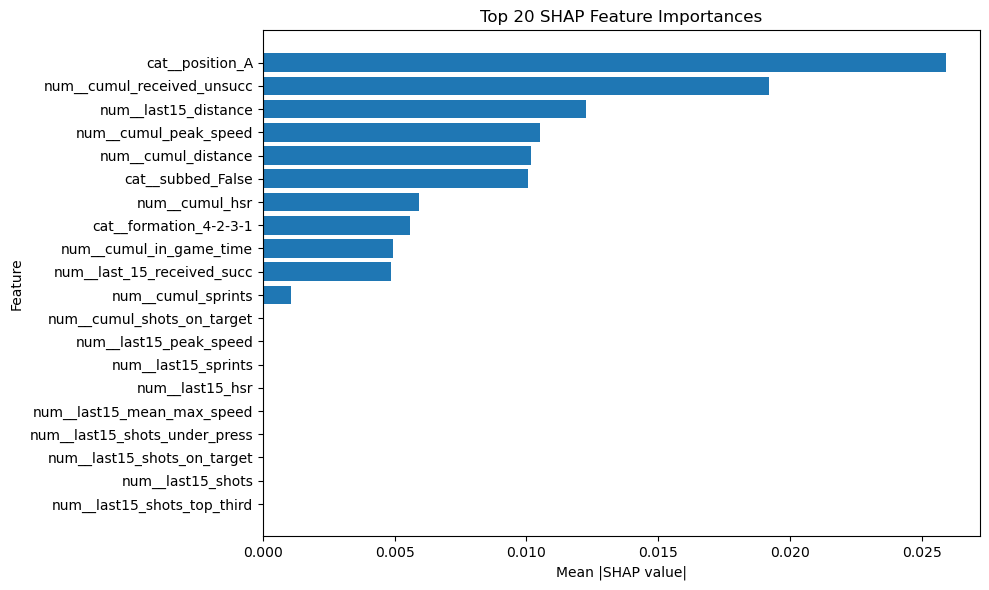

In [101]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# fitted objects from your pipeline
preprocessor_fitted = tree_pipe.named_steps["preprocessor"]
tree_model = tree_pipe.named_steps["model"]

# transform validation data
X_val_transformed = preprocessor_fitted.transform(X_val_df)

# convert sparse matrix to dense if needed
if hasattr(X_val_transformed, "toarray"):
    X_val_transformed = X_val_transformed.toarray()

# transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()

# dataframe for readability
X_val_transformed_df = pd.DataFrame(
    X_val_transformed,
    columns=feature_names,
    index=X_val_df.index
)

# compute SHAP values
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_val_transformed_df)

# make SHAP output consistently 2D: (n_samples, n_features)
if isinstance(shap_values, list):
    # older SHAP: list of arrays, take positive class
    shap_values_2d = np.array(shap_values[1])
else:
    shap_values_2d = np.array(shap_values)

    # possible shapes:
    # (n_samples, n_features)
    # (n_samples, n_features, 2)
    # (n_samples, 2, n_features)
    if shap_values_2d.ndim == 3:
        if shap_values_2d.shape[2] == 2:
            # shape: (n_samples, n_features, n_classes)
            shap_values_2d = shap_values_2d[:, :, 1]
        elif shap_values_2d.shape[1] == 2:
            # shape: (n_samples, n_classes, n_features)
            shap_values_2d = shap_values_2d[:, 1, :]

# mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values_2d).mean(axis=0)

# importance table
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print(shap_importance.head(20))

# histogram-style importance plot (horizontal bar chart)
top_n = 20
plot_df = shap_importance.head(top_n).sort_values("mean_abs_shap", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(f"Top {top_n} SHAP Feature Importances")
plt.tight_layout()
plt.show()

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train_df, y_train)

y_val_pred = rf_pipe.predict(X_val_df)
y_val_prob = rf_pipe.predict_proba(X_val_df)[:, 1]

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_prob))
print(classification_report(y_val, y_val_pred))

y_test_pred = rf_pipe.predict(X_test_df)
y_test_prob = rf_pipe.predict_proba(X_test_df)[:, 1]

print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_prob))
print(classification_report(y_test, y_test_pred))

Validation accuracy: 0.932824427480916
Validation ROC AUC: 0.6476714774587115
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       611
           1       0.00      0.00      0.00        44

    accuracy                           0.93       655
   macro avg       0.47      0.50      0.48       655
weighted avg       0.87      0.93      0.90       655

Test accuracy: 0.9541864139020537
Test ROC AUC: 0.7397236812057547
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       604
           1       0.00      0.00      0.00        29

    accuracy                           0.95       633
   macro avg       0.48      0.50      0.49       633
weighted avg       0.91      0.95      0.93       633



C:\Users\yana1\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yana1\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yana1\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yana1\anaconda3\Lib

Categorical columns used:
['checkpoint', 'position', 'is_home', 'formation', 'subbed']


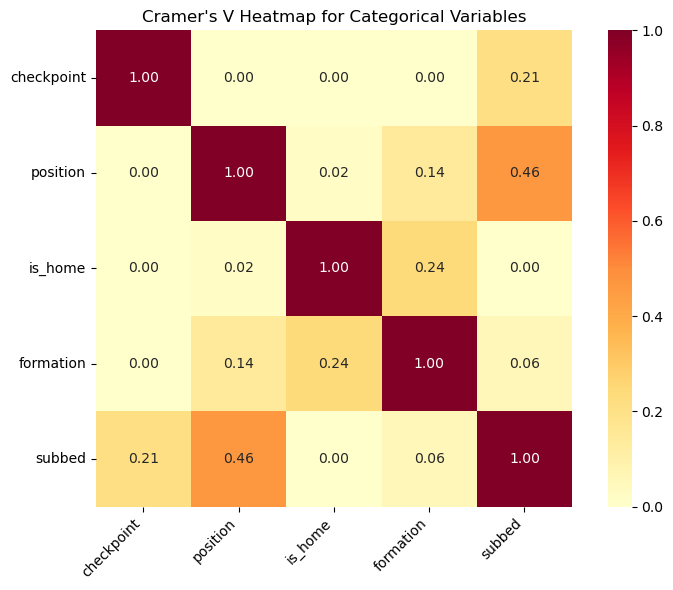

,checkpoint,position,is_home,formation,subbed
checkpoint,1.000000,0.000000,0.000000,0.000000,0.213393
position,0.000000,1.000000,0.020413,0.144191,0.463529
is_home,0.000000,0.020413,1.000000,0.238816,0.000000
formation,0.000000,0.144191,0.238816,1.000000,0.056145
subbed,0.213393,0.463529,0.000000,0.056145,1.000000


In [123]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# --- pick categorical columns ---
cat_cols = train.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

# optional: drop target / IDs / date-like columns if you don't want them in the heatmap
drop_if_present = ["scored_after", "fixture_id", "date"]
cat_cols = [c for c in cat_cols if c not in drop_if_present]

print("Categorical columns used:")
print(cat_cols)

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)

    # if one variable has only one level after dropping NAs, association is undefined
    if confusion.shape[0] < 2 or confusion.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(confusion, correction=False)[0]
    n = confusion.to_numpy().sum()
    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = confusion.shape

    # bias correction
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)

# --- compute matrix ---
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            pair = train[[col1, col2]].dropna()
            cramers_v_matrix.loc[col1, col2] = cramers_v(pair[col1], pair[col2])

# --- plot heatmap ---
plt.figure(figsize=(max(8, len(cat_cols) * 0.8), max(6, len(cat_cols) * 0.7)))
sns.heatmap(
    cramers_v_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    square=True
)
plt.title("Cramer's V Heatmap for Categorical Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

cramers_v_matrix

In [127]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr

target = "scored_after"

# pick numeric columns only
num_cols = train.select_dtypes(include=["number"]).columns.tolist()

# remove the binary dependent variable itself
num_predictors = [col for col in num_cols if col != target]

results = []

for col in num_predictors:
    tmp = train[[target, col]].dropna()

    # safety checks
    if tmp[target].nunique() != 2:
        continue
    if tmp[col].nunique() < 2:
        continue

    r, p = pointbiserialr(tmp[target], tmp[col])

    results.append({
        "variable": col,
        "point_biserial_r": r,
        "abs_r": abs(r),
        "p_value": p,
        "mean_when_0": tmp.loc[tmp[target] == 0, col].mean(),
        "mean_when_1": tmp.loc[tmp[target] == 1, col].mean(),
        "std_when_0": tmp.loc[tmp[target] == 0, col].std(),
        "std_when_1": tmp.loc[tmp[target] == 1, col].std()
    })

pb_results = pd.DataFrame(results).sort_values("abs_r", ascending=False).reset_index(drop=True)

print(pb_results)

                    variable  point_biserial_r     abs_r   p_value  \
0         cumul_in_game_time         -0.096251  0.096251  0.000027   
1      cumul_received_unsucc         -0.090228  0.090228  0.000083   
2    last_15_received_unsucc         -0.071184  0.071184  0.001926   
3          last15_peak_speed          0.068970  0.068970  0.002658   
4      last15_mean_max_speed          0.065260  0.065260  0.004472   
5                 last15_hsr          0.060646  0.060646  0.008257   
6               last15_shots          0.046655  0.046655  0.042227   
7     last15_shots_top_third          0.044802  0.044802  0.051117   
8            last15_distance          0.040023  0.040023  0.081458   
9        cumul_received_succ         -0.040010  0.040010  0.081556   
10             cumul_sprints         -0.039462  0.039462  0.085829   
11            cumul_distance         -0.035379  0.035379  0.123561   
12  last15_shots_under_press          0.034096  0.034096  0.137788   
13      cumul_mean_m